IRON Kaggle - Sales Prediction
To solve - Sales Regression 
Evaluation Metric - R2 score, evaluation


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"_pydevd_bundle.pydevd_constants.Null\"}]\n","stderr":"","mime":[]}


In [4]:
df = pd.read_csv('/Users/sazao/ProjectChallenge/training.csv')
print('Shape:', df.shape)
df.head()

Shape: (640840, 10)


,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   Unnamed: 0           640840 non-null  int64
 1   store_ID             640840 non-null  int64
 2   day_of_week          640840 non-null  int64
 3   date                 640840 non-null  str  
 4   nb_customers_on_day  640840 non-null  int64
 5   open                 640840 non-null  int64
 6   promotion            640840 non-null  int64
 7   state_holiday        640840 non-null  str  
 8   school_holiday       640840 non-null  int64
 9   sales                640840 non-null  int64
dtypes: int64(8), str(2)
memory usage: 48.9 MB


In [6]:
df.describe()

,Unnamed: 0,store_ID,day_of_week,nb_customers_on_day,open,promotion,school_holiday,sales
count,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000
mean,355990.675084,558.211348,4.000189,633.398577,0.830185,0.381718,0.178472,5777.469011
std,205536.290268,321.878521,1.996478,464.094416,0.375470,0.485808,0.382910,3851.338083
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,178075.750000,280.000000,2.000000,405.000000,1.000000,0.000000,0.000000,3731.000000
50%,355948.500000,558.000000,4.000000,609.000000,1.000000,0.000000,0.000000,5746.000000
75%,533959.250000,837.000000,6.000000,838.000000,1.000000,1.000000,0.000000,7860.000000
max,712044.000000,1115.000000,7.000000,5458.000000,1.000000,1.000000,1.000000,41551.000000


In [7]:
df.isnull().sum()

Unnamed: 0             0
store_ID               0
day_of_week            0
date                   0
nb_customers_on_day    0
open                   0
promotion              0
state_holiday          0
school_holiday         0
sales                  0
dtype: int64

In [8]:
print("School holidays:", df["school_holiday"].unique())
print("State Holidays:", df["state_holiday"].unique())
print("Promotion:", df["promotion"].unique())
print("Open:", df["open"].value_counts())  ### drop and check accuracy


School holidays: [0 1]
State Holidays: <StringArray>
['0', 'a', 'c', 'b']
Length: 4, dtype: str
Promotion: [0 1]
Open: open
1    532016
0    108824
Name: count, dtype: int64


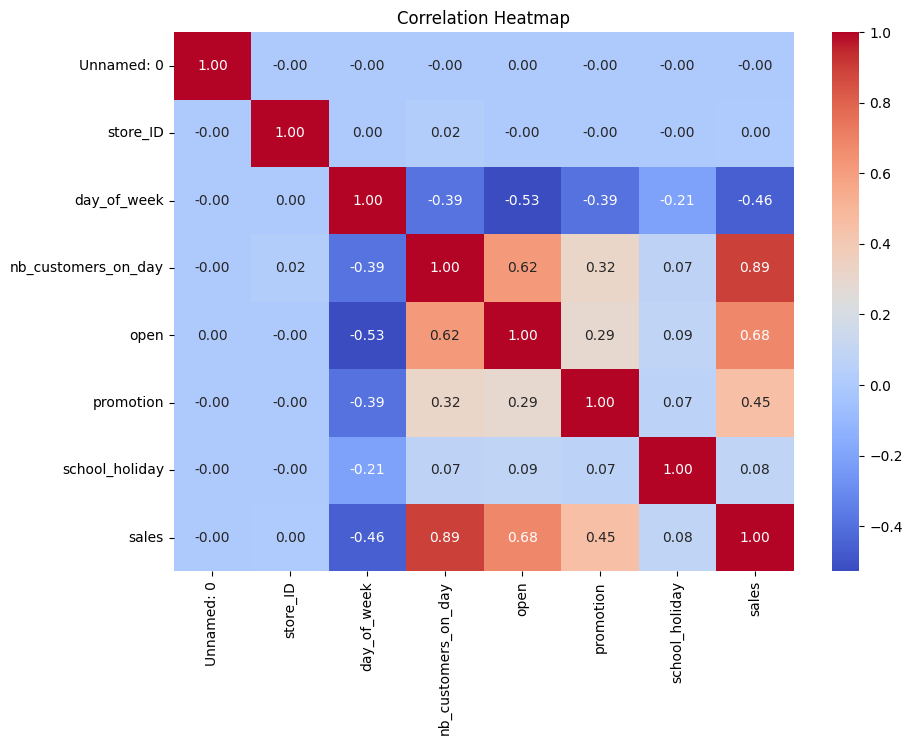

In [9]:
plt.figure(figsize=(10, 7))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


Data Cleaning

In [11]:
##some cleaning and datapre processing 


In [13]:
#remove collumn index 'umnamed'
df_clean = df[df['open'] == 1].copy()
print(f'Rows before filtering: {len(df)}')
print(f'Rows after filtering (open only): {len(df_clean)}')
# Drop the index column and 'open' (all 1s now)
df_clean.drop(columns=['Unnamed: 0', 'open'], inplace=True)
print('Dropped: Unnamed: 0, open')
df_clean.head()

Rows before filtering: 640840
Rows after filtering (open only): 532016
Dropped: Unnamed: 0, open


,store_ID,day_of_week,date,nb_customers_on_day,promotion,state_holiday,school_holiday,sales
0,366,4,2013-04-18,517,0,0,0,4422
1,394,6,2015-04-11,694,0,0,0,8297
2,807,4,2013-08-29,970,1,0,0,9729
3,802,2,2013-05-28,473,1,0,0,6513
4,726,4,2013-10-10,1068,1,0,0,10882


10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"_pydevd_bundle.pydevd_constants.Null\"}]\n","stderr":"","mime":[]}


In [16]:
#processing Date collumn
df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean['month']        = df_clean['date'].dt.month
df_clean['year']         = df_clean['date'].dt.year
df_clean['week']         = df_clean['date'].dt.isocalendar().week.astype(int)
df_clean['day_of_month'] = df_clean['date'].dt.day
df_clean['is_weekend']   = (df_clean['day_of_week'] >= 6).astype(int)
print('New date features added: month, year, week, day_of_month, is_weekend')
df_clean[['date','month','year','week','day_of_month','is_weekend']].head()
# Encode state_holiday: '0'=no holiday, 'a'=public, 'b'=Easter, 'c'=Christmas
le = LabelEncoder()
df_clean['state_holiday_enc'] = le.fit_transform(df_clean['state_holiday'])
print('state_holiday encoding mapping:')
for label, code in zip(le.classes_, le.transform(le.classes_)):
    print(f'  {label!r} -> {code}')

10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"_pydevd_bundle.pydevd_constants.Null\"}]\n","stderr":"","mime":[]}
New date features added: month, year, week, day_of_month, is_weekend
state_holiday encoding mapping:
  '0' -> 0
  'a' -> 1
  'b' -> 2
  'c' -> 3


10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"_pydevd_bundle.pydevd_constants.Null\"}]\n","stderr":"","mime":[]}
10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"_pydevd_bundle.pydevd_constants.Null\"}]\n","stderr":"","mime":[]}
10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\

In [17]:
#transform to numeric
numeric_cols = [
    "nb_customers_on_day",
    "open",
    "promotion",
    "school_holiday",
    "day_of_week"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [18]:
#final encoding
df = pd.get_dummies(df, drop_first=False)

Split

In [23]:
X = df.drop(columns=["sales"])
y = df["sales"]

Train test 

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_val.shape)

(512672, 953) (128168, 953)


In [ ]:
### date formatting

In [ ]:
### modeling
## linear regression, random forest, gradient boosting

10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"_pydevd_bundle.pydevd_constants.Null\"}]\n","stderr":"","mime":[]}
10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"_pydevd_bundle.pydevd_constants.Null\"}]\n","stderr":"","mime":[]}


In [25]:
#linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_val)

r2_lr = r2_score(y_val, pred_lr)
print("Linear Regression R²:", r2_lr)

Linear Regression R²: 0.8709039680368609


In [26]:
#random forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_val)

r2_rf = r2_score(y_val, pred_rf)
print("Random Forest R²:", r2_rf)

0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.


KeyboardInterrupt: 

In [27]:
#gradient boosting
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

gbr.fit(X_train, y_train)

pred_gbr = gbr.predict(X_val)

r2_gbr = r2_score(y_val, pred_gbr)
print("Gradient Boosting R²:", r2_gbr)

KeyboardInterrupt: 

In [ ]:
#picking best model
best_model_name = results.iloc[0]["Model"]
print("Best model:", best_model_name)
